# Water boundary, local tariffs and trade-offs

Indonesia only. A/E/B/S labels and source boundaries remain in datasets. These calculations are scenarios, not metered national data-center electricity or water. See docs/methodology.md.

In [1]:
from pathlib import Path
import sys
root = Path.cwd().resolve()
while not (root / 'assumptions.yaml').exists():
    if root == root.parent: raise FileNotFoundError('Run from within the research repository')
    root = root.parent
sys.path.insert(0, str(root / 'src'))
import pandas as pd
from IPython.display import display, Image
from config import read_dataset, assumptions


In [2]:
display(read_dataset('wue_benchmarks'))
display(read_dataset('water_tariffs'))

,company,facility,country,wue_l_per_kwh,cooling_type,year,source_id,data_class,notes,water_measure,denominator,source_year,scope,measurement_status,reported_unit,reported_wue_value,value_precision,forecast_start_year,forecast_end_year
0,Digital Edge,EDGE1 Jakarta,Indonesia,NaN,Not disclosed,NaN,WB008,S,Undated webpage labels Annual WUE but gives no...,water use unspecified,Not disclosed,NaN,EDGE1 Jakarta,published_specification_definition_unverified,Not disclosed,1.082,NaN,NaN,NaN
1,Digital Edge,EDGE2 Jakarta,Indonesia,NaN,Closed-loop hybrid cooling towers described in...,NaN,WB008,S,Undated webpage labels Annual WUE but gives no...,water use unspecified,Not disclosed,NaN,EDGE2 Jakarta,published_specification_definition_unverified,Not disclosed,1.082,NaN,NaN,NaN
2,Microsoft,Global fleet,Global / Global,0.30,NaN,2024.0,WB013,B,NON-INDONESIAN benchmark. Cooling/humidificati...,water use unspecified,IT electricity,2024.0,Global fleet,reported_fiscal_year_actual,NaN,NaN,NaN,NaN,NaN
3,Microsoft,Asia Pacific fleet,Global / Asia Pacific,0.03,NaN,2024.0,WB013,B,NON-INDONESIAN benchmark. Cooling/humidificati...,water use unspecified,IT electricity,2024.0,Asia Pacific fleet,reported_fiscal_year_actual,NaN,NaN,NaN,NaN,NaN
4,Microsoft,Global fleet,Global / Global,0.27,NaN,2025.0,WB013,B,NON-INDONESIAN benchmark. Cooling/humidificati...,water use unspecified,IT electricity,2025.0,Global fleet,reported_fiscal_year_actual,NaN,NaN,NaN,NaN,NaN
5,Microsoft,Asia Pacific fleet,Global / Asia Pacific,0.25,NaN,2025.0,WB013,B,NON-INDONESIAN benchmark. Cooling/humidificati...,water use unspecified,IT electricity,2025.0,Asia Pacific fleet,reported_fiscal_year_actual,NaN,NaN,NaN,NaN,NaN
6,AWS,Global fleet,Global,0.15,NaN,2024.0,WB014,B,NON-INDONESIAN water withdrawn per IT-load ene...,withdrawal,IT electricity,2024.0,Global fleet,reported_calendar_year_actual,NaN,NaN,NaN,NaN,NaN
7,AWS,Global fleet,Global,0.12,NaN,2025.0,WB014,B,NON-INDONESIAN water withdrawn per IT-load ene...,withdrawal,IT electricity,2025.0,Global fleet,reported_calendar_year_actual,NaN,NaN,NaN,NaN,NaN
8,Google,LLM-serving data centers,Global,1.15,NaN,2023.0,WB016,B,NON-INDONESIAN freshwater Category2 WUE: input...,consumption,IT electricity,2023.0,LLM-serving data centers,reported_annual_actual,NaN,NaN,NaN,NaN,NaN
9,Google,LLM-serving data centers,Global,1.15,NaN,2024.0,WB016,B,NON-INDONESIAN freshwater Category2 WUE: input...,consumption,IT electricity,2024.0,LLM-serving data centers,reported_annual_actual,NaN,NaN,NaN,NaN,NaN


,location,provider,customer_category,consumption_band,tariff_rp_per_m3,effective_date,source_id,data_class,notes,band_min_m3,band_max_m3,tariff_status,secondary_source_id,source_locator,reported_range_low_rp_per_m3,reported_range_high_rp_per_m3
0,Jakarta,PAM JAYA,K III Niaga/Industri Kecil,0-10 m3/month,4900.0,2025-01-01,WB001,A,Published local marginal block tariff; monthly...,0.0,10.0,effective_date_verified_contract_unverified,WB002,"PDF p2 (index1), KelompokKIII or Khusus; month...",NaN,NaN
1,Jakarta,PAM JAYA,K III Niaga/Industri Kecil,11-20 m3/month,9500.0,2025-01-01,WB001,A,Published local marginal block tariff; monthly...,11.0,20.0,effective_date_verified_contract_unverified,WB002,"PDF p2 (index1), KelompokKIII or Khusus; month...",NaN,NaN
2,Jakarta,PAM JAYA,K III Niaga/Industri Kecil,>20 m3/month,12500.0,2025-01-01,WB001,A,Published local marginal block tariff; monthly...,21.0,NaN,effective_date_verified_contract_unverified,WB002,"PDF p2 (index1), KelompokKIII or Khusus; month...",NaN,NaN
3,Jakarta,PAM JAYA,K III Niaga/Industri Menengah,0-10 m3/month,6825.0,2025-01-01,WB001,A,Published local marginal block tariff; monthly...,0.0,10.0,effective_date_verified_contract_unverified,WB002,"PDF p2 (index1), KelompokKIII or Khusus; month...",NaN,NaN
4,Jakarta,PAM JAYA,K III Niaga/Industri Menengah,11-20 m3/month,12500.0,2025-01-01,WB001,A,Published local marginal block tariff; monthly...,11.0,20.0,effective_date_verified_contract_unverified,WB002,"PDF p2 (index1), KelompokKIII or Khusus; month...",NaN,NaN
5,Jakarta,PAM JAYA,K III Niaga/Industri Menengah,>20 m3/month,17500.0,2025-01-01,WB001,A,Published local marginal block tariff; monthly...,21.0,NaN,effective_date_verified_contract_unverified,WB002,"PDF p2 (index1), KelompokKIII or Khusus; month...",NaN,NaN
6,Jakarta,PAM JAYA,K III Niaga/Industri Besar,0-10 m3/month,12550.0,2025-01-01,WB001,A,Published local marginal block tariff; monthly...,0.0,10.0,effective_date_verified_contract_unverified,WB002,"PDF p2 (index1), KelompokKIII or Khusus; month...",NaN,NaN
7,Jakarta,PAM JAYA,K III Niaga/Industri Besar,11-20 m3/month,17500.0,2025-01-01,WB001,A,Published local marginal block tariff; monthly...,11.0,20.0,effective_date_verified_contract_unverified,WB002,"PDF p2 (index1), KelompokKIII or Khusus; month...",NaN,NaN
8,Jakarta,PAM JAYA,K III Niaga/Industri Besar,>20 m3/month,21500.0,2025-01-01,WB001,A,Published local marginal block tariff; monthly...,21.0,NaN,effective_date_verified_contract_unverified,WB002,"PDF p2 (index1), KelompokKIII or Khusus; month...",NaN,NaN
9,Jakarta,PAM JAYA,Kelompok Khusus Kesepakatan Komersial,Commercial agreement,NaN,2025-01-01,WB001,A,Negotiated rate; source says at least full tar...,NaN,NaN,negotiated_rate_not_disclosed,NaN,"PDF p2 (index1), KelompokKIII or Khusus; month...",NaN,NaN


In [3]:
from water_model import water
base = read_dataset('additional_1gw').query('case == "base"').iloc[0]
display(pd.DataFrame([water(base.it_electricity_kwh, base.wue_l_per_kwh, base.water_tariff_rp_per_m3)]))
assert base.water_m3_per_year == base.it_electricity_kwh * base.wue_l_per_kwh / 1000

,water_liters_per_year,water_million_liters_per_year,water_m3_per_year,water_m3_per_day,water_cost_rp,monthly_water_cost_rp,actual_water_withdrawal_m3,actual_water_consumption_m3,water_metric
0,3.504000e+09,3504.0,3504000.0,9600.0,7.533600e+10,6.278000e+09,None,None,Scenario direct on-site consumption; no observ...


wue_l_per_kwh,0.0,0.2,0.5,1.0,1.5
pue,,,,,
1.1,7.683669e+12,7.713804e+12,7.759005e+12,7.834341e+12,7.909677e+12
1.2,8.382185e+12,8.412319e+12,8.457521e+12,8.532857e+12,8.608193e+12
1.3,9.080700e+12,9.110834e+12,9.156036e+12,9.231372e+12,9.306708e+12
1.4,9.779215e+12,9.809350e+12,9.854551e+12,9.929887e+12,1.000522e+13
1.5,1.047773e+13,1.050787e+13,1.055307e+13,1.062840e+13,1.070374e+13


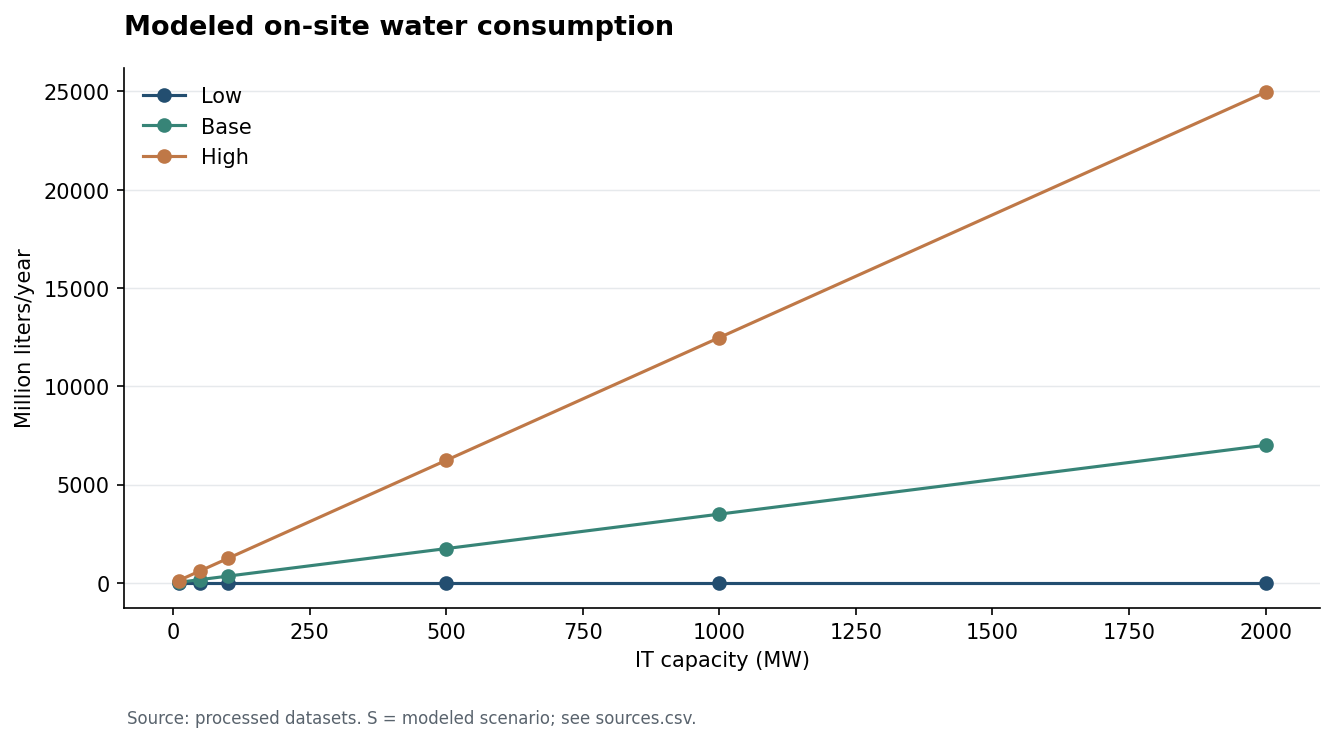

In [4]:
grid = read_dataset('cooling_tradeoff')
display(grid.pivot(index='pue', columns='wue_l_per_kwh', values='total_resource_cost_rp'))
display(Image(filename=str(root / 'outputs/charts/06_water_consumption.png')))